# HR diagram & dimensionality reduction

We can use samples of measured data to train a data-driven basis that better explains it.

In [4]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x121009f50>)

In [5]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [7]:
ce = LabelEncoder()
df_stars['Star color'] = ce.fit_transform(df_stars['Star color'])
colors = ce.inverse_transform(df_stars['Star color'])
color_names = ce.classes_
print(color_names)

['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']


In [8]:
sc = LabelEncoder()
df_stars['Spectral Class'] = sc.fit_transform(df_stars['Spectral Class'])
spectral_classes = sc.inverse_transform(df_stars['Spectral Class'])
spectral_class_names = sc.classes_
print(spectral_class_names)

['A' 'B' 'F' 'G' 'K' 'M' 'O']


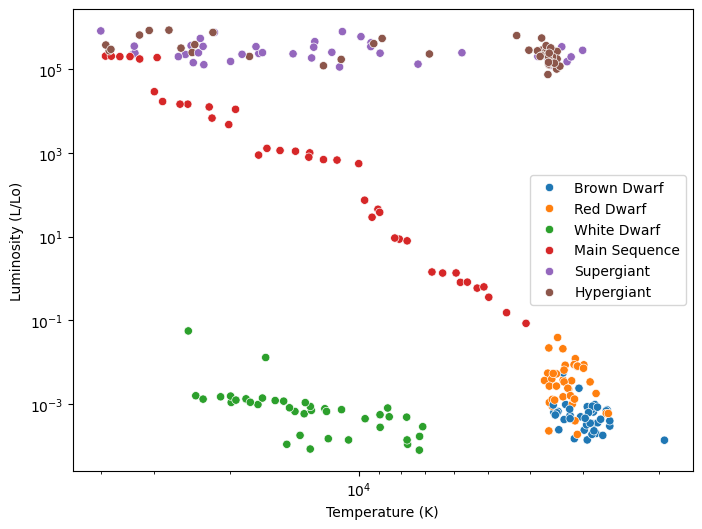

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=le.inverse_transform(df_stars['Star type'].values),
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()

Preprocessing data allow for a better analysis. **Put in log scale!**

In [10]:
from sklearn.decomposition import PCA
import numpy as np
import sklearn.preprocessing as preprocessing

In [38]:
data = df_stars.drop(columns=['Star type', 'Star color', 'Spectral Class'])

# Standardize the data manually

data_log = data.copy()
data_log.iloc[:, :2] = np.log1p(data.iloc[:, :2])
data_scaled = (data_log - data_log.mean()) / data_log.std()

n_components = len(data.columns)

pca = PCA(n_components, svd_solver='full')
pca.fit(data_scaled)

eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [2.62015691 0.98301653 0.3502628  0.04656376]
Eigenvectors:
 [[-0.32002684 -0.59050263 -0.43793694  0.59757904]
 [ 0.8122873   0.00132097 -0.58318772  0.00892657]
 [ 0.48681937 -0.42956265  0.68223482  0.33621196]
 [ 0.02791179  0.68321361  0.05156522  0.72786065]]


/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_35959/3705261977.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       8.029107
1       8.020599
2       7.863651
3       7.937732
4       7.570443
         ...    
235    10.569803
236    10.336568
237     9.085910
238     9.130864
239    10.542258
Name: Temperature (K), Length: 240, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_log.iloc[:, :2] = np.log1p(data.iloc[:, :2])


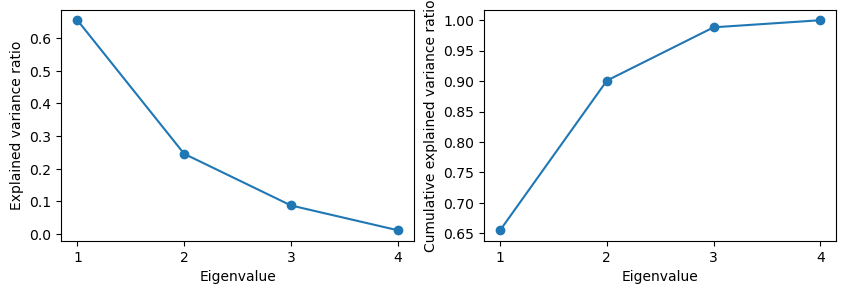

In [39]:
evals = pca.explained_variance_ratio_

fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)
ax.plot(range(1, n_components+1), evals)
ax.scatter(range(1, n_components+1), evals)
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Explained variance ratio")
ax.set_xticks(range(1, n_components+1))

ax = fig.add_subplot(122)
ax.plot(range(1, n_components+1), evals.cumsum())
ax.scatter(range(1, n_components+1), evals.cumsum())
ax.set_xticks(range(1, n_components+1))
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Cumulative explained variance ratio")

plt.show()

In [40]:
cum_evals = evals.cumsum()
print("Explained variance ratio for 3 component:", cum_evals[2])
print("Explained variance ratio for 2 component:", cum_evals[1])

Explained variance ratio for 3 component: 0.9883590587648448
Explained variance ratio for 2 component: 0.9007933598003699


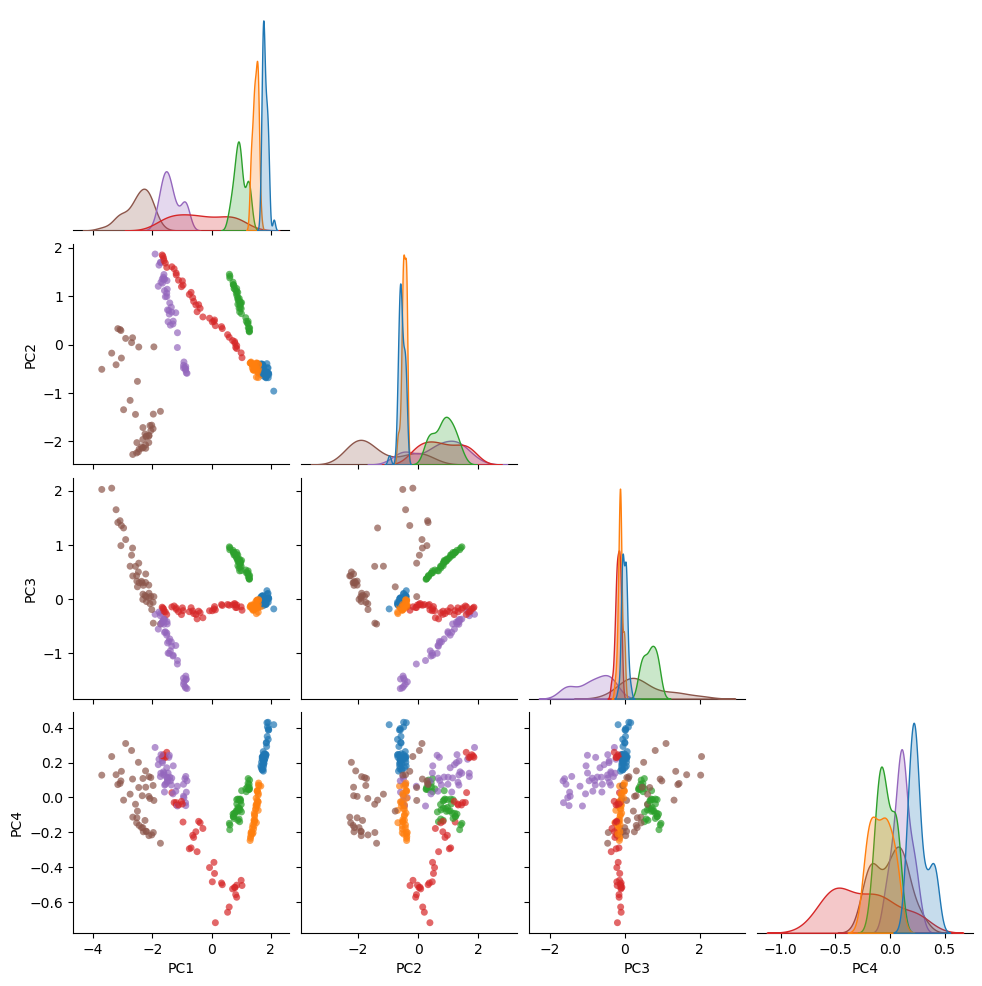

In [41]:
data_scaled_pca = pca.transform(data_scaled)

pc_columns = [f"PC{i+1}" for i in range(data_scaled_pca.shape[1])]
pc_df = pd.DataFrame(data_scaled_pca, columns=pc_columns)
pc_df["Star type"] = le.inverse_transform(df_stars["Star type"].values)

g = sns.pairplot(
    pc_df,
    vars=pc_columns,
    hue="Star type",
    corner=True,
    plot_kws={"alpha": 0.7, "s": 25, "edgecolor": "none"},
)

if hasattr(g, "_legend") and g._legend is not None:
    g._legend.remove()
plt.show()

Let's use now KMeans after dimensionality reduction. I will use 2 principal component and try to see if KMeans is capable of reconize the Star Type label.

In [52]:
n_components = 2
n_clusters = 6

In [53]:
data_scaled_pca_cl = data_scaled_pca[:, :n_components]

In [54]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(data_scaled_pca_cl)
kmeans_labels = kmeans.labels_

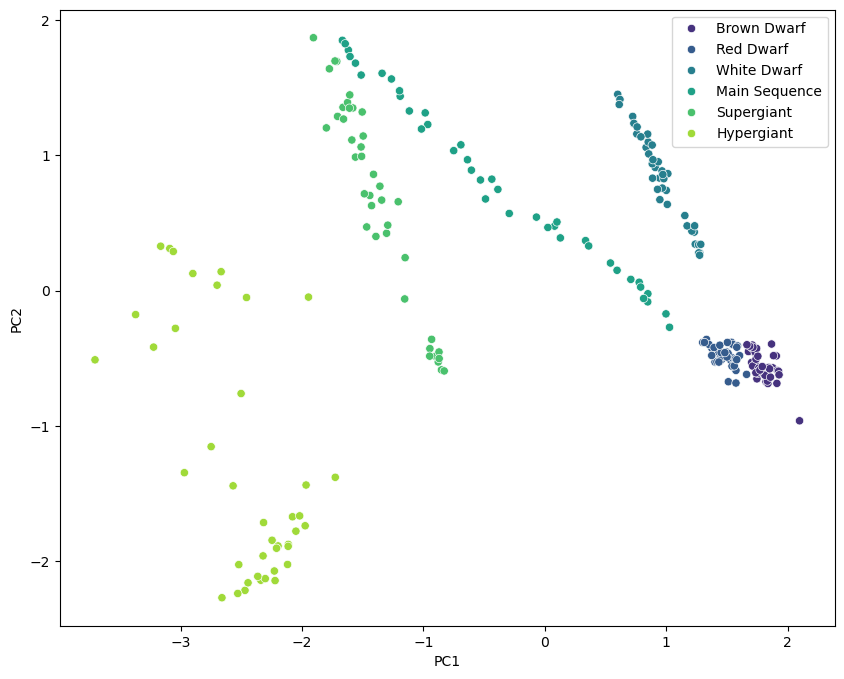

In [55]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_scaled_pca_cl[:, 0], y=data_scaled_pca_cl[:, 1], hue=labels, palette='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

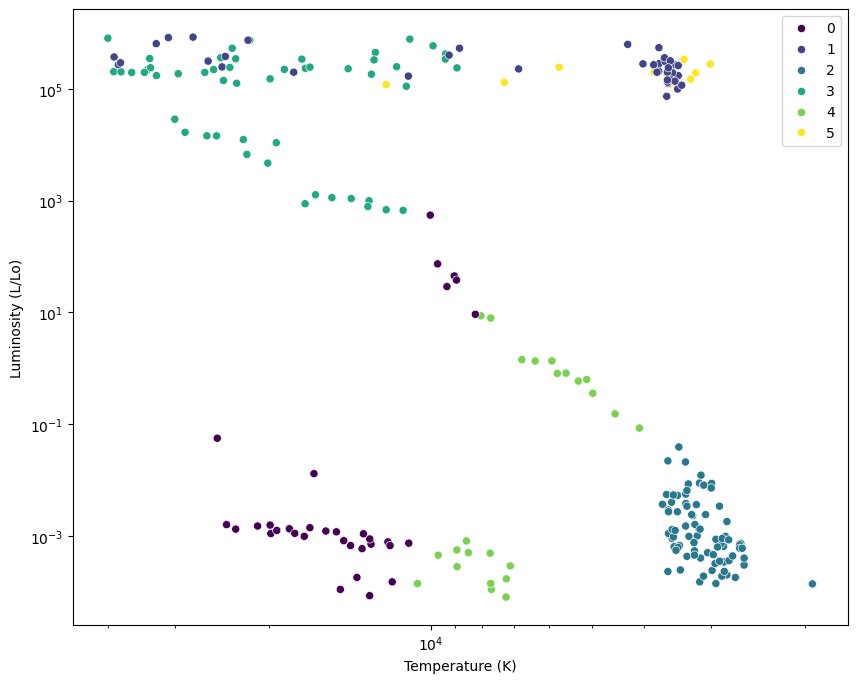

In [56]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=kmeans_labels,
    palette='viridis',
    s=35,
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()

### A powerfull technique: t-SNE

In [65]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [66]:
tSNE = make_pipeline(StandardScaler(), TSNE(n_components=2, random_state=42))
data_tSNE = tSNE.fit_transform(data)

data_tSNE.shape

(240, 2)

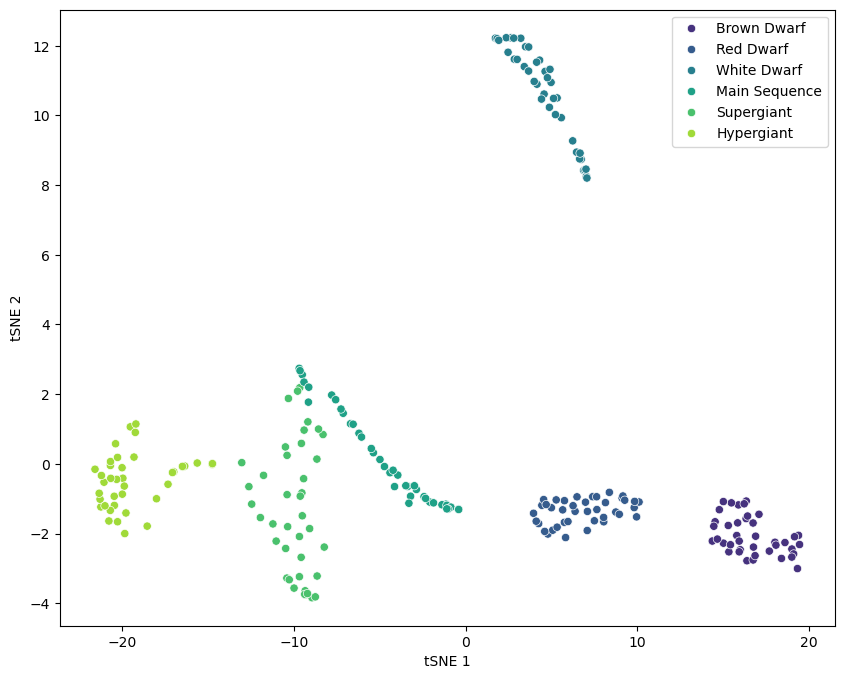

In [67]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_tSNE[:, 0], y=data_tSNE[:, 1], hue=le.inverse_transform(df_stars['Star type']), palette='viridis')
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.show()

This what's obtained by already know the original classification, and it's remarkable indeed. 

Probabily running a KMeans algorithm on this reduced dataset will be more succesfull.

In [68]:
kmeans_tSNE = KMeans(n_clusters=6, random_state=42)
kmeans_tSNE.fit(data_tSNE)

kmeans_tSNE_labels = kmeans_tSNE.labels_

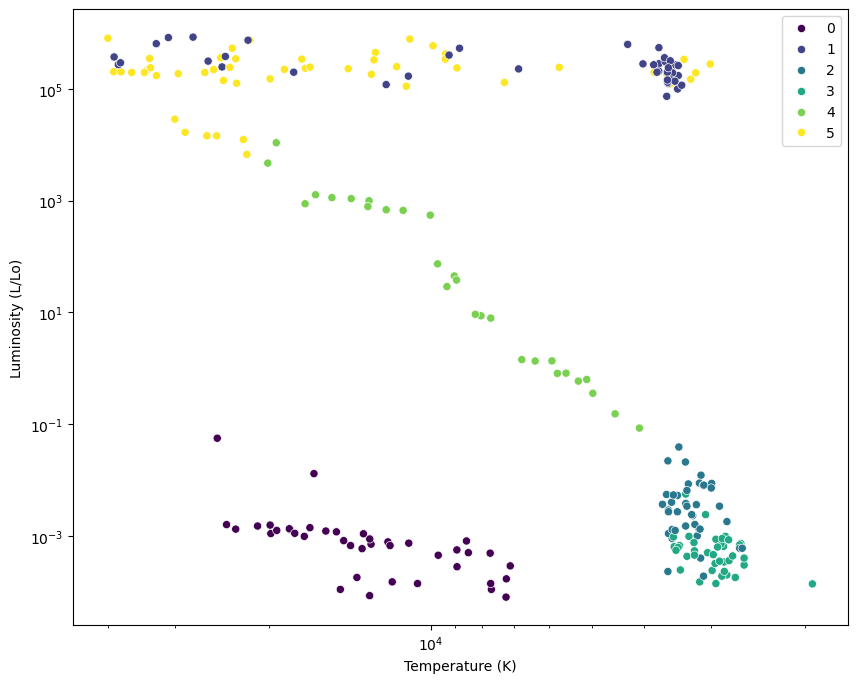

In [69]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=kmeans_tSNE_labels,
    palette='viridis',
    s=35,
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()

### Run a classifer for Star Type

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [71]:
Y = le.inverse_transform(df_stars['Star type'])
X = df_stars.drop(columns=['Star type', 'Star color', 'Spectral Class'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [72]:
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
gscv = GridSearchCV(
    estimator=RandomForestClassifier(n_estimators=200, random_state=42),
    param_grid={
        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    },
    cv=5,
    scoring='roc_auc_ovr',
    n_jobs=-1
)

gscv.fit(X_train_scaled, Y_train)
print("Best parameters:", gscv.best_params_)

Best parameters: {'max_depth': 2}


In [74]:
rf = RandomForestClassifier(n_estimators=100, max_depth=gscv.best_params_['max_depth'], random_state=42)
rf.fit(X_train_scaled, Y_train)
rf_predictions = rf.predict(X_test_scaled)
cm = confusion_matrix(Y_test, rf_predictions)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 8  0  0  0  0  0]
 [ 0 11  0  0  0  0]
 [ 0  0  8  0  0  0]
 [ 0  0  0  7  0  0]
 [ 0  0  0  0  8  0]
 [ 0  0  0  0  0  6]]


In [75]:
accuracy = rf.score(X_test_scaled, Y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0
